# Rough Heston Model — fBM-Driven Volatility with $H \approx 0.1$

The **Rough Heston model** (El Euch & Rosenbaum, 2016–2019) extends the classical Heston stochastic volatility model by replacing the Brownian driver in the variance equation with a **fractional kernel** $(t-s)^{H-1/2}$. The dynamics under the risk-neutral measure are:

$$
\begin{aligned}
dS_t &= S_t \sqrt{V_t} \, dW_t \\[4pt]
V_t &= V_0 + \frac{1}{\Gamma(\alpha)} \int_0^t (t-s)^{\alpha-1} \lambda(\theta - V_s)\,ds + \frac{1}{\Gamma(\alpha)} \int_0^t (t-s)^{\alpha-1} \nu\sqrt{V_s}\,dB_s
\end{aligned}
$$

where $\alpha = H + \tfrac{1}{2}$, $\langle dW_t, dB_t \rangle = \rho\,dt$, and $H \in (0,1)$ is the Hurst parameter.

When $H = 0.5$, the kernel becomes $(t-s)^0/\Gamma(1) = 1$ and we recover the classical **CIR** variance process. When $H \approx 0.1$ (the empirically observed value for log-volatility; Gatheral, Jaisson & Rosenbaum 2018), the kernel is $(t-s)^{-0.4}$ — **strongly singular near the diagonal**. This creates:
- **Ultra-rough** volatility paths (Hölder regularity $\approx 0.1$)
- **Exploding ATM skew** at short maturities ($\psi(\tau) \sim \tau^{H-1/2}$)
- A **non-Markovian**, infinite-memory variance process

We simulate via a Riemann-sum Euler convolution scheme. The variance equation is a stochastic Volterra equation; at each time step we convolve the entire history with the singular kernel.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma

# ============================================================
# Rough Heston Simulator (Riemann-sum Euler convolution)
# ============================================================

def rough_heston_paths(T, n, H, V0, lambda_param, theta, nu, rho, seed=None):
    """
    Simulate the rough Heston model via Euler convolution.
    
    Parameters
    ----------
    T : float
        Time horizon.
    n : int
        Number of time steps.
    H : float
        Hurst parameter (0 < H < 1).
    V0, lambda_param, theta, nu, rho : model parameters
    seed : int, optional
    
    Returns
    -------
    t, V, S : arrays of shape (n+1,)
        Time grid, variance path, asset price path.
    """
    if seed is not None:
        np.random.seed(seed)
    dt = T / n
    t = np.linspace(0, T, n + 1)
    
    # Volterra kernel K(u) = u^{H-0.5} / Gamma(H+0.5)
    alpha_k = H - 0.5
    lags = np.arange(1, n + 1) * dt
    K_vals = lags**alpha_k / Gamma(H + 0.5)
    
    # Correlated Brownian increments
    dB = np.random.randn(n) * np.sqrt(dt)
    dZ = np.random.randn(n) * np.sqrt(dt)
    dW = rho * dB + np.sqrt(1.0 - rho**2) * dZ
    
    V = np.zeros(n + 1)
    V[0] = V0
    logS = np.zeros(n + 1)
    logS[0] = 0.0  # log(S0/S0)
    
    for j in range(1, n + 1):
        # Convolution: sum_{i=0}^{j-1} K((j-i)*dt) * [drift_i + diff_i]
        kernel = K_vals[:j][::-1]  # K(dt), K(2dt), ..., K(j*dt)
        
        drift = lambda_param * (theta - V[:j]) * dt
        diff = nu * np.sqrt(np.maximum(V[:j], 0.0)) * dB[:j]
        
        V[j] = V0 + np.sum(kernel * (drift + diff))
        V[j] = max(V[j], 0.0)  # absorb at zero
        
        # Log-Euler for the asset price (r = 0)
        v_sqrt = np.sqrt(max(V[j - 1], 0.0))
        logS[j] = logS[j - 1] - 0.5 * V[j - 1] * dt + v_sqrt * dW[j - 1]
    
    S = np.exp(logS)
    return t, V, S


def autocorr(x, max_lag=50):
    """Normalized autocorrelation function."""
    x = x - np.mean(x)
    corr = np.correlate(x, x, mode='full')
    corr = corr[len(corr) // 2:]
    corr = corr / corr[0]
    return corr[:max_lag + 1]


print("Setup complete. rough_heston_paths() defined.")


Setup complete. rough_heston_paths() defined.


## The Singular Volterra Kernel

The kernel $K(u) = u^{H-1/2} / \Gamma(H+1/2)$ is the heart of rough volatility. For $H < 0.5$, it explodes as $u \to 0$. This means **recent shocks receive infinite weight** in the limit, creating the jagged, anti-persistent paths characteristic of rough volatility.

For $H = 0.1$, the singularity is $u^{-0.4}$. Compare this to $H = 0.5$ (classical Heston), where the kernel is flat ($K(u) = 1$).


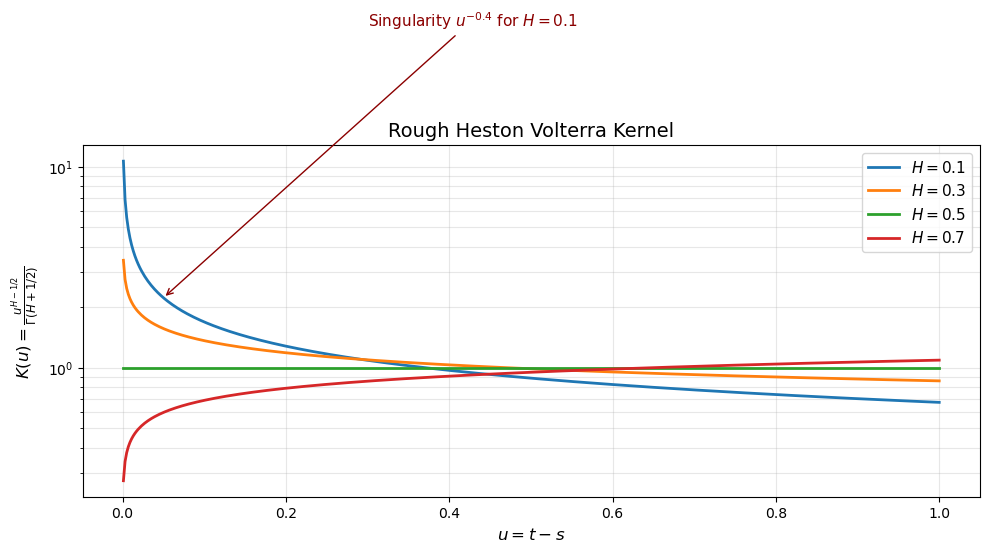

In [2]:
u = np.linspace(0.001, 1.0, 500)
H_vals = [0.1, 0.3, 0.5, 0.7]

fig, ax = plt.subplots(figsize=(10, 6))
for H in H_vals:
    K = u**(H - 0.5) / Gamma(H + 0.5)
    ax.plot(u, K, linewidth=2, label=rf"$H = {H}$")

ax.set_xlabel(r"$u = t-s$", fontsize=12)
ax.set_ylabel(r"$K(u) = \frac{u^{H-1/2}}{\Gamma(H+1/2)}$", fontsize=12)
ax.set_title("Rough Heston Volterra Kernel", fontsize=14)
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

# Annotation for H=0.1
ax.annotate(rf"Singularity $u^{{-0.4}}$ for $H=0.1$",
            xy=(0.05, 0.05**(-0.4) / Gamma(0.6)),
            xytext=(0.3, 50),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=11, color='darkred')

plt.tight_layout()
plt.show()


## Variance Paths — From Classical to Ultra-Rough

We simulate variance paths for $H \in \{0.1, 0.3, 0.5, 0.7\}$ using identical Brownian shocks. Notice how $H=0.1$ produces **extremely erratic, jagged paths** with Hölder regularity $\approx 0.1$, while $H=0.5$ recovers the comparatively smooth CIR diffusion.

The parameter values are typical: $V_0 = \theta = 0.04$ (20% volatility), mean reversion $\lambda = 2.0$, vol-of-vol $\nu = 0.3$, and leverage correlation $\rho = -0.7$.


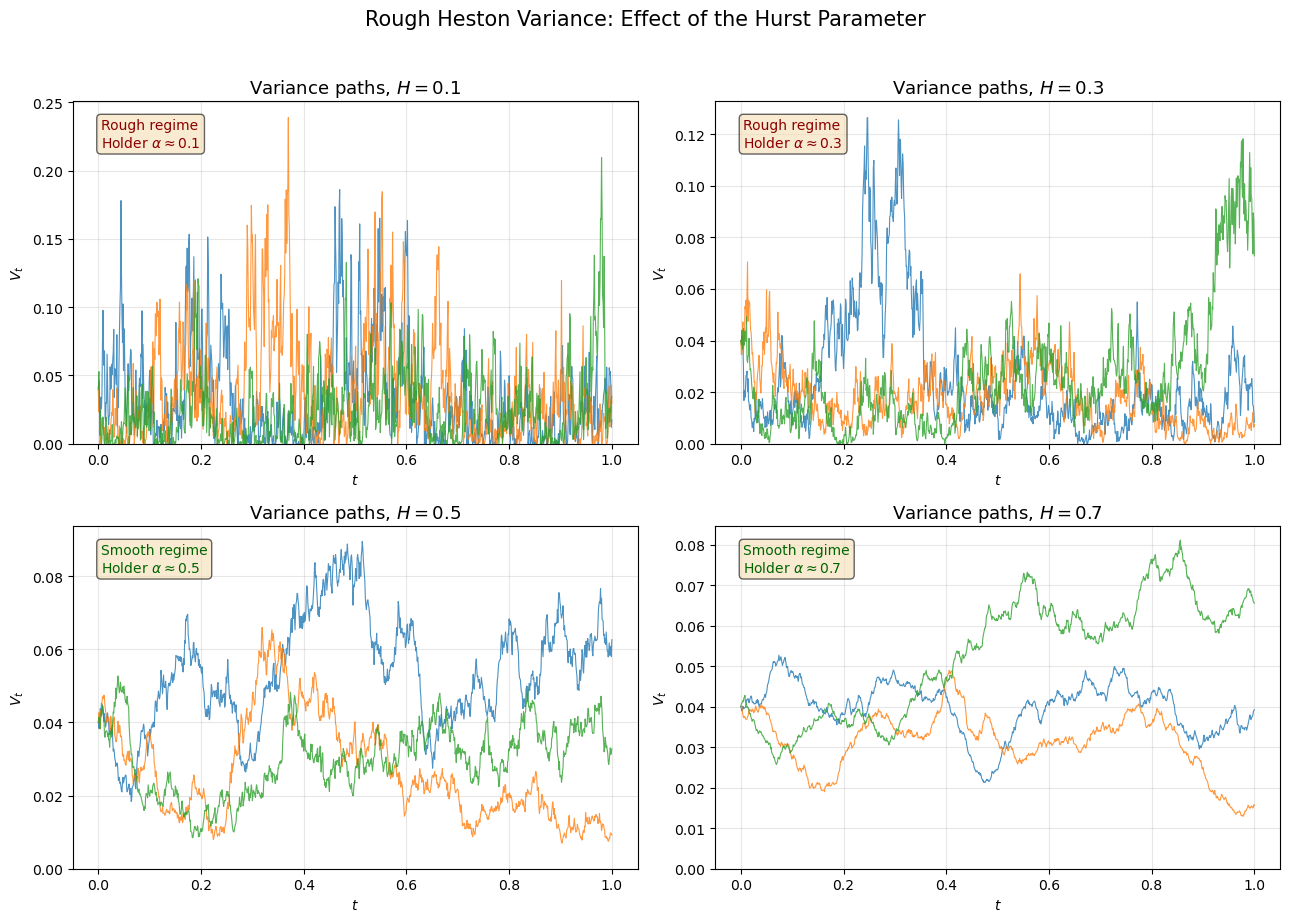

In [3]:
# Common parameters
T = 1.0
n = 1000
V0 = 0.04
theta = 0.04
lambda_param = 2.0
nu = 0.3
rho = -0.7
seed = 42

H_vals = [0.1, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, H in zip(axes.flat, H_vals):
    # Simulate 3 paths with different seeds but same H
    for k in range(3):
        t, V, _ = rough_heston_paths(T, n, H, V0, lambda_param, theta, nu, rho,
                                     seed=seed + k * 100 + int(10 * H))
        ax.plot(t, V, linewidth=0.8, alpha=0.8)
    
    ax.set_title(rf"Variance paths, $H = {H}$", fontsize=13)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$V_t$")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0.0)
    
    if H < 0.5:
        info = rf"Rough regime" + "\n" + rf"Holder $\alpha \approx {H}$"
        color = 'darkred'
    else:
        info = rf"Smooth regime" + "\n" + rf"Holder $\alpha \approx {H}$"
        color = 'darkgreen'
    
    ax.text(0.05, 0.95, info, transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6),
            color=color)

plt.suptitle("Rough Heston Variance: Effect of the Hurst Parameter", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## Joint Asset Price and Variance — The Leverage Effect

For $H \approx 0.1$, the volatility path is so rough that it appears to "vibrate" at a much higher frequency than the asset price. Yet the correlation $\rho = -0.7$ preserves the **leverage effect**: volatility spikes coincide with downward price moves.

This plot shows a single trajectory. The roughness of $V_t$ is visually striking — it looks almost like a high-frequency noise process superimposed on a slower mean-reversion.


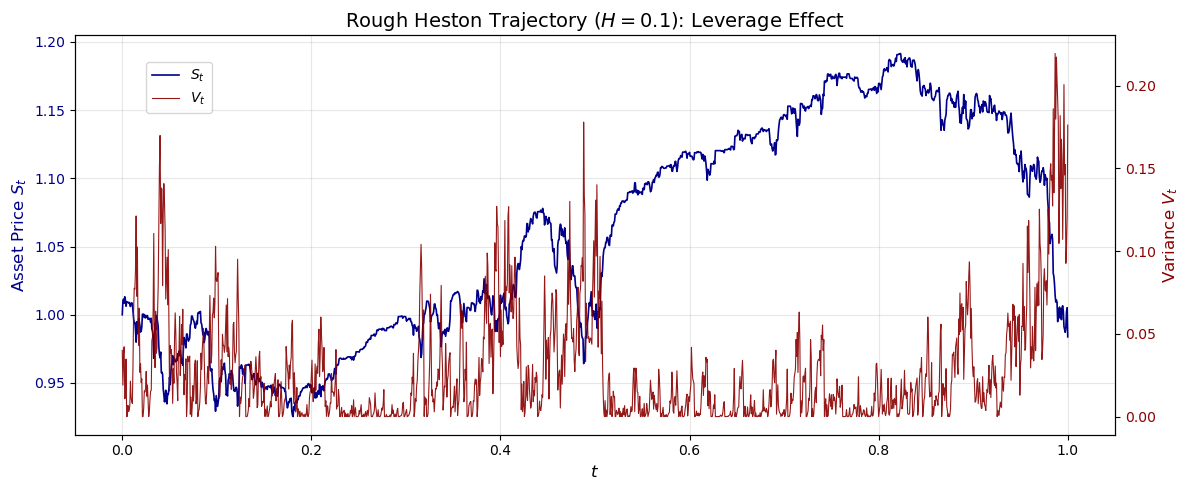

In [4]:
H = 0.1
t, V, S = rough_heston_paths(T=1.0, n=1500, H=H, V0=V0, lambda_param=lambda_param,
                             theta=theta, nu=nu, rho=rho, seed=123)

fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = 'darkblue'
ax1.plot(t, S, color=color1, linewidth=1.2, label=r"$S_t$")
ax1.set_xlabel(r"$t$", fontsize=12)
ax1.set_ylabel(r"Asset Price $S_t$", color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'darkred'
ax2.plot(t, V, color=color2, linewidth=0.8, alpha=0.9, label=r"$V_t$")
ax2.set_ylabel(r"Variance $V_t$", color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Shade regions where V is high and S drops
ax1.set_title(rf"Rough Heston Trajectory ($H = {H}$): Leverage Effect", fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ATM Skew Term Structure — The Signature of Roughness

One of the most compelling empirical facts motivating rough volatility is the **term structure of the ATM skew**. In equity markets (e.g. S&P 500), the ATM skew explodes like $\tau^{-0.4}$ as maturity $\tau \to 0$.

In a model driven by fBM with Hurst $H$, the ATM skew scales as:

$$ \psi(\tau) \;\sim\; \tau^{H - 1/2} $$

- **Classical Heston** ($H = 0.5$): $\psi(\tau) \sim \tau^0 = \text{constant}$. The skew is flat at short maturities — **empirically false**.
- **Rough Heston** ($H \approx 0.1$): $\psi(\tau) \sim \tau^{-0.4}$. The skew explodes at short maturities — **exactly what we observe**.

This single stylized fact, reproduced with only 3–4 parameters, is why rough volatility has become dominant in derivatives modeling.


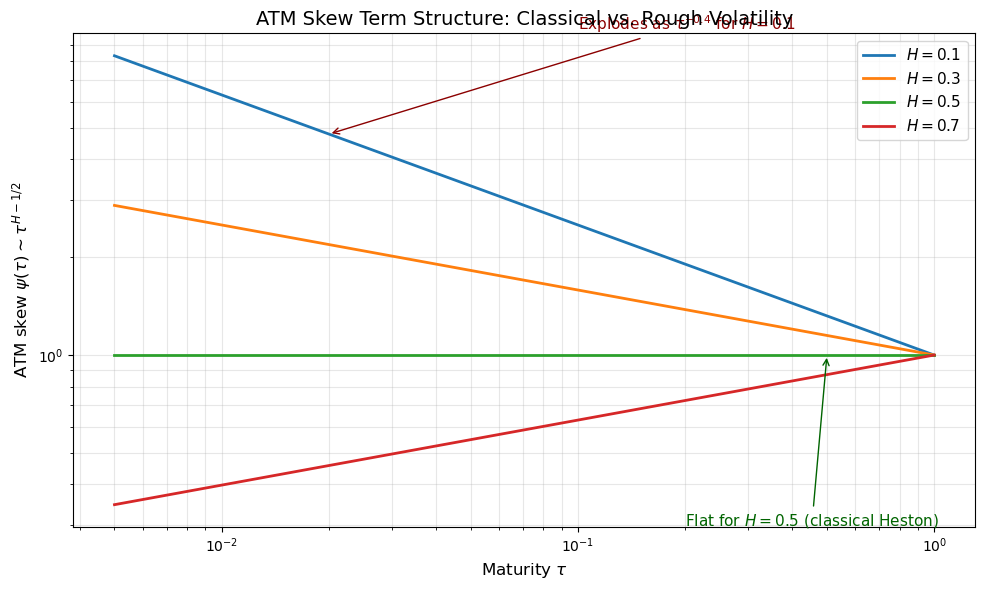

In [5]:
tau = np.linspace(0.005, 1.0, 200)
H_skew = [0.1, 0.3, 0.5, 0.7]

fig, ax = plt.subplots(figsize=(10, 6))
for H in H_skew:
    skew = tau**(H - 0.5)
    ax.plot(tau, skew, linewidth=2, label=rf"$H = {H}$")

ax.set_xlabel(r"Maturity $\tau$", fontsize=12)
ax.set_ylabel(r"ATM skew $\psi(\tau) \sim \tau^{H-1/2}$", fontsize=12)
ax.set_title("ATM Skew Term Structure: Classical vs. Rough Volatility", fontsize=14)
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

ax.annotate(rf"Explodes as $\tau^{{-0.4}}$ for $H=0.1$",
            xy=(0.02, 0.02**(-0.4)), xytext=(0.1, 10),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=11, color='darkred')

ax.annotate(rf"Flat for $H=0.5$ (classical Heston)",
            xy=(0.5, 1.0), xytext=(0.2, 0.3),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=11, color='darkgreen')

plt.tight_layout()
plt.show()


## Empirical Validation — Log-Volatility Scaling Law

Gatheral et al. (2018) showed that the increments of **log-realized volatility** satisfy the fBM scaling law:

$$ m_q(\Delta) = \mathbb{E}\left[ \left| \log V_{t+\Delta} - \log V_t \right|^q \right] \;\propto\; \Delta^{qH} $$

By regressing $\log m_q(\Delta)$ against $\log \Delta$, the slope gives $qH$, so $H$ can be estimated as $\zeta_q / q$. For true fBM, this estimate is **independent of $q$** and equals $H$.

We verify this on a long simulated rough Heston path with $H = 0.1$. The estimated scaling exponents should cluster near $0.1$.


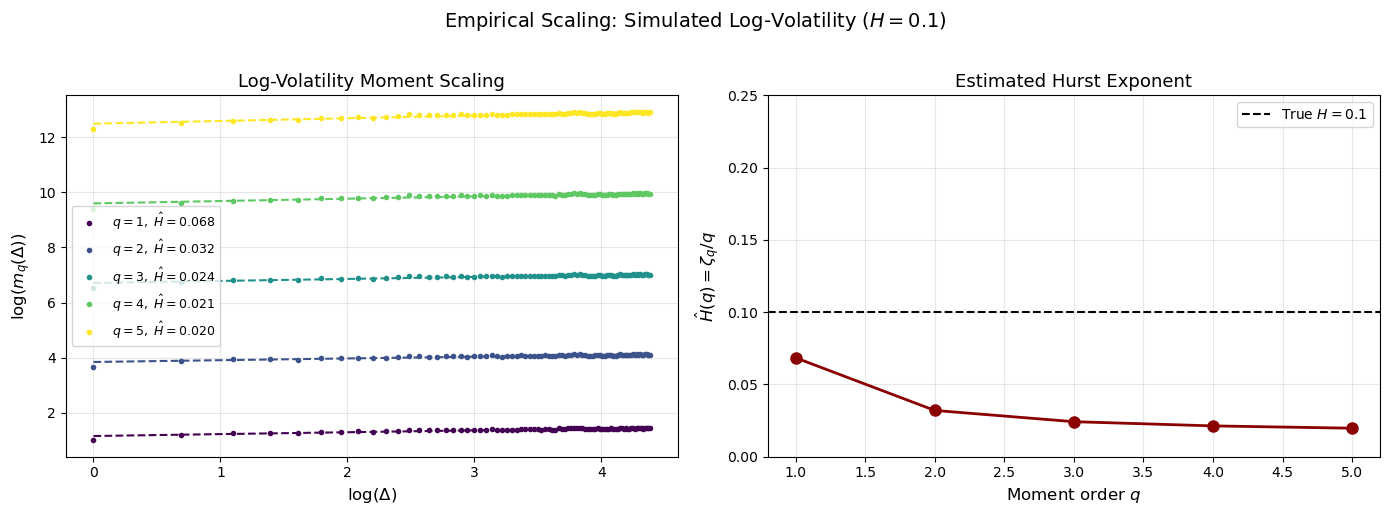

In [6]:
# Generate one long path for scaling analysis
T_long = 3.0
n_long = 3000
t_long, V_long, _ = rough_heston_paths(T_long, n_long, H=0.1, V0=V0,
                                        lambda_param=lambda_param, theta=theta,
                                        nu=nu, rho=rho, seed=999)

logV = np.log(np.maximum(V_long, 1e-10))
q_vals = [1, 2, 3, 4, 5]
max_lag = 80
lags = np.arange(1, max_lag + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

H_ests = []
colors = plt.cm.viridis(np.linspace(0, 1, len(q_vals)))

for idx, q in enumerate(q_vals):
    moments = []
    for lag in lags:
        diffs = np.abs(logV[lag:] - logV[:-lag])
        moments.append(np.mean(diffs**q))
    moments = np.array(moments)
    
    log_lags = np.log(lags)
    log_mom = np.log(moments)
    slope, intercept = np.polyfit(log_lags, log_mom, 1)
    H_est = slope / q
    H_ests.append(H_est)
    
    axes[0].plot(log_lags, log_mom, 'o', markersize=3, color=colors[idx],
                 label=rf"$q={q},\ \hat{{H}}={H_est:.3f}$")
    axes[0].plot(log_lags, slope * log_lags + intercept, '--', color=colors[idx])

axes[0].set_xlabel(r"$\log(\Delta)$", fontsize=12)
axes[0].set_ylabel(r"$\log(m_q(\Delta))$", fontsize=12)
axes[0].set_title("Log-Volatility Moment Scaling", fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(q_vals, H_ests, 'o-', color='darkred', markersize=8, linewidth=2)
axes[1].axhline(0.1, color='black', linestyle='--', linewidth=1.5, label=rf"True $H = 0.1$")
axes[1].set_xlabel(r"Moment order $q$", fontsize=12)
axes[1].set_ylabel(r"$\hat{H}(q) = \zeta_q / q$", fontsize=12)
axes[1].set_title("Estimated Hurst Exponent", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.0, 0.25)

plt.suptitle(rf"Empirical Scaling: Simulated Log-Volatility ($H = 0.1$)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Autocorrelation of Log-Volatility Increments

For $H < 0.5$, fBM increments are **negatively correlated** and anti-persistent. The autocorrelation of log-volatility increments decays slowly and stays negative — a hallmark of roughness. For $H = 0.5$ (Brownian motion), increments are uncorrelated. For $H > 0.5$, they are positively correlated (long memory).

We compare the autocorrelation structure for $H = 0.1$ vs. $H = 0.5$ on simulated rough Heston variance.


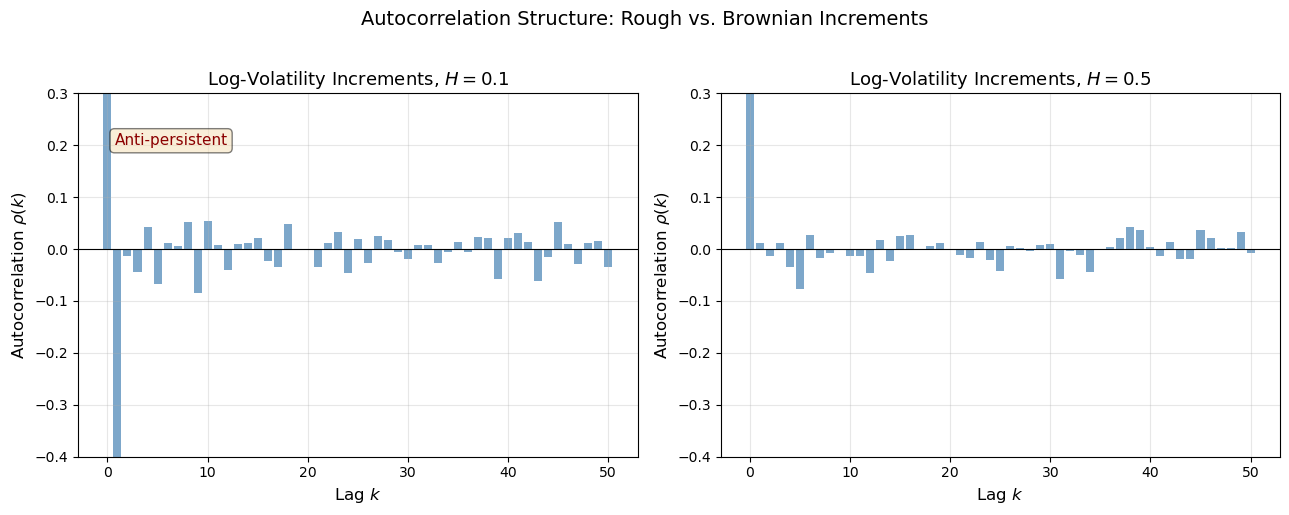

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, H in zip(axes, [0.1, 0.5]):
    t_sim, V_sim, _ = rough_heston_paths(2.0, 2000, H, V0, lambda_param, theta, nu, rho,
                                          seed=777)
    logV_sim = np.log(np.maximum(V_sim, 1e-10))
    inc = np.diff(logV_sim)
    acf = autocorr(inc, max_lag=50)
    lags_acf = np.arange(len(acf))
    
    ax.bar(lags_acf, acf, color='steelblue', alpha=0.7, width=0.8)
    ax.axhline(0.0, color='black', linewidth=0.8)
    ax.set_xlabel(r"Lag $k$", fontsize=12)
    ax.set_ylabel(r"Autocorrelation $\rho(k)$", fontsize=12)
    ax.set_title(rf"Log-Volatility Increments, $H = {H}$", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.4, 0.3)
    
    if H < 0.5:
        ax.text(0.7, 0.2, rf"Anti-persistent", fontsize=11, color='darkred',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Autocorrelation Structure: Rough vs. Brownian Increments", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## The Fractional Riccati Equation

A remarkable result of El Euch & Rosenbaum (2019) is that the Rough Heston model admits a **closed-form characteristic function** — just like classical Heston — but the Riccati ODE is replaced by a **fractional Riccati equation**:

$$ D^\alpha \psi(\tau) = \frac{1}{2}(u^2 - u) + (\rho \nu u - \lambda)\psi(\tau) + \frac{1}{2}\nu^2 \psi(\tau)^2 $$

where $D^\alpha$ is the **Caputo fractional derivative** of order $\alpha = H + 1/2 \approx 0.6$. The initial condition is $\psi(0) = 0$ (for a flat forward variance curve).

Because of the fractional derivative, the solution $\psi(\tau)$ has **memory**: its value at $\tau$ depends on the entire history $\{\psi(s) : 0 \leq s \leq \tau\}$, not just on $\psi(\tau)$. This is the analytical counterpart to the non-Markovian simulation.

For $H = 0.5$ ($\alpha = 1$), $D^1$ is the ordinary derivative and we recover the classical Riccati ODE.


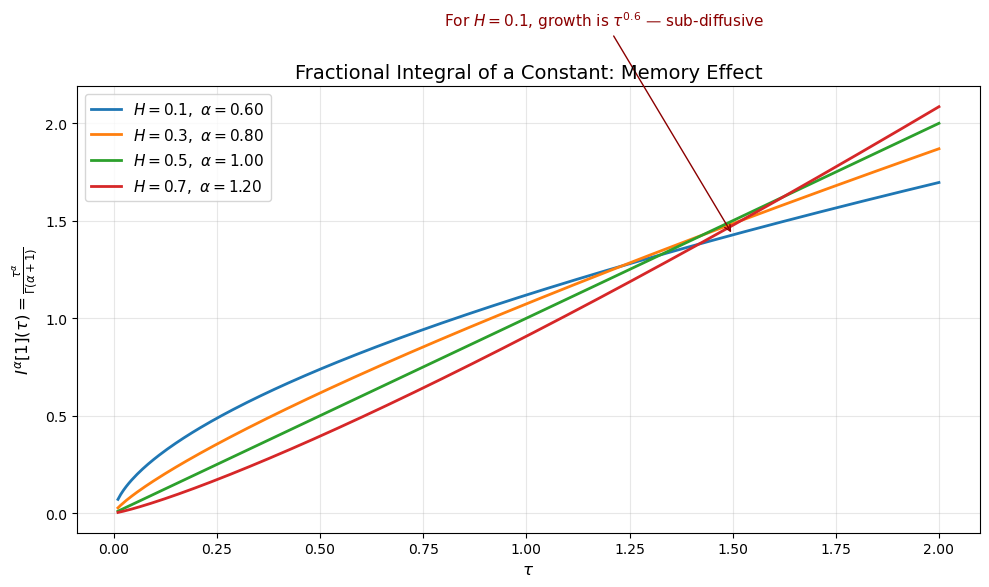

In [8]:
# Illustrate the Caputo fractional integral I^alpha f(t) for f(s)=1
# I^alpha 1 = t^alpha / Gamma(alpha+1)
# This shows how fractional integration "slows down" growth.

tau = np.linspace(0.01, 2.0, 300)
H_vals = [0.1, 0.3, 0.5, 0.7]
alphas = [H + 0.5 for H in H_vals]

fig, ax = plt.subplots(figsize=(10, 6))
for H, alpha in zip(H_vals, alphas):
    I_alpha = tau**alpha / Gamma(alpha + 1)
    ax.plot(tau, I_alpha, linewidth=2, label=rf"$H = {H},\ \alpha = {alpha:.2f}$")

ax.set_xlabel(r"$\tau$", fontsize=12)
ax.set_ylabel(r"$I^\alpha[1](\tau) = \frac{\tau^\alpha}{\Gamma(\alpha+1)}$", fontsize=12)
ax.set_title("Fractional Integral of a Constant: Memory Effect", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax.annotate(rf"For $H=0.1$, growth is $\tau^{{0.6}}$ — sub-diffusive",
            xy=(1.5, 1.5**0.6 / Gamma(1.6)), xytext=(0.8, 2.5),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=11, color='darkred')

plt.tight_layout()
plt.show()


## Summary — Classical Heston vs. Rough Heston

| Feature | Classical Heston ($H = 0.5$) | Rough Heston ($H \approx 0.1$) |
|---------|------------------------------|--------------------------------|
| **Driver** | Standard Brownian motion | Fractional kernel $(t-s)^{H-1/2}$ |
| **Path regularity** | Hölder $1/2 - \epsilon$ | Hölder $0.1 - \epsilon$ |
| **Memory** | Markovian | Non-Markovian, power-law memory |
| **Short-maturity skew** | Flat | Explodes as $\tau^{H-1/2}$ |
| **Parameters** | 5+ parameters | 3–4 parameters fit the whole surface |
| **Characteristic function** | Riccati ODE | **Fractional** Riccati equation |
| **Rough path theory** | Standard Itô calculus | Needs branched RP / regularity structures for $H \leq 1/4$ |

The Rough Heston model is not just a mathematical curiosity. It is one of the most empirically successful stochastic volatility models in modern quantitative finance, capturing the **roughness** of volatility with remarkable parsimony.


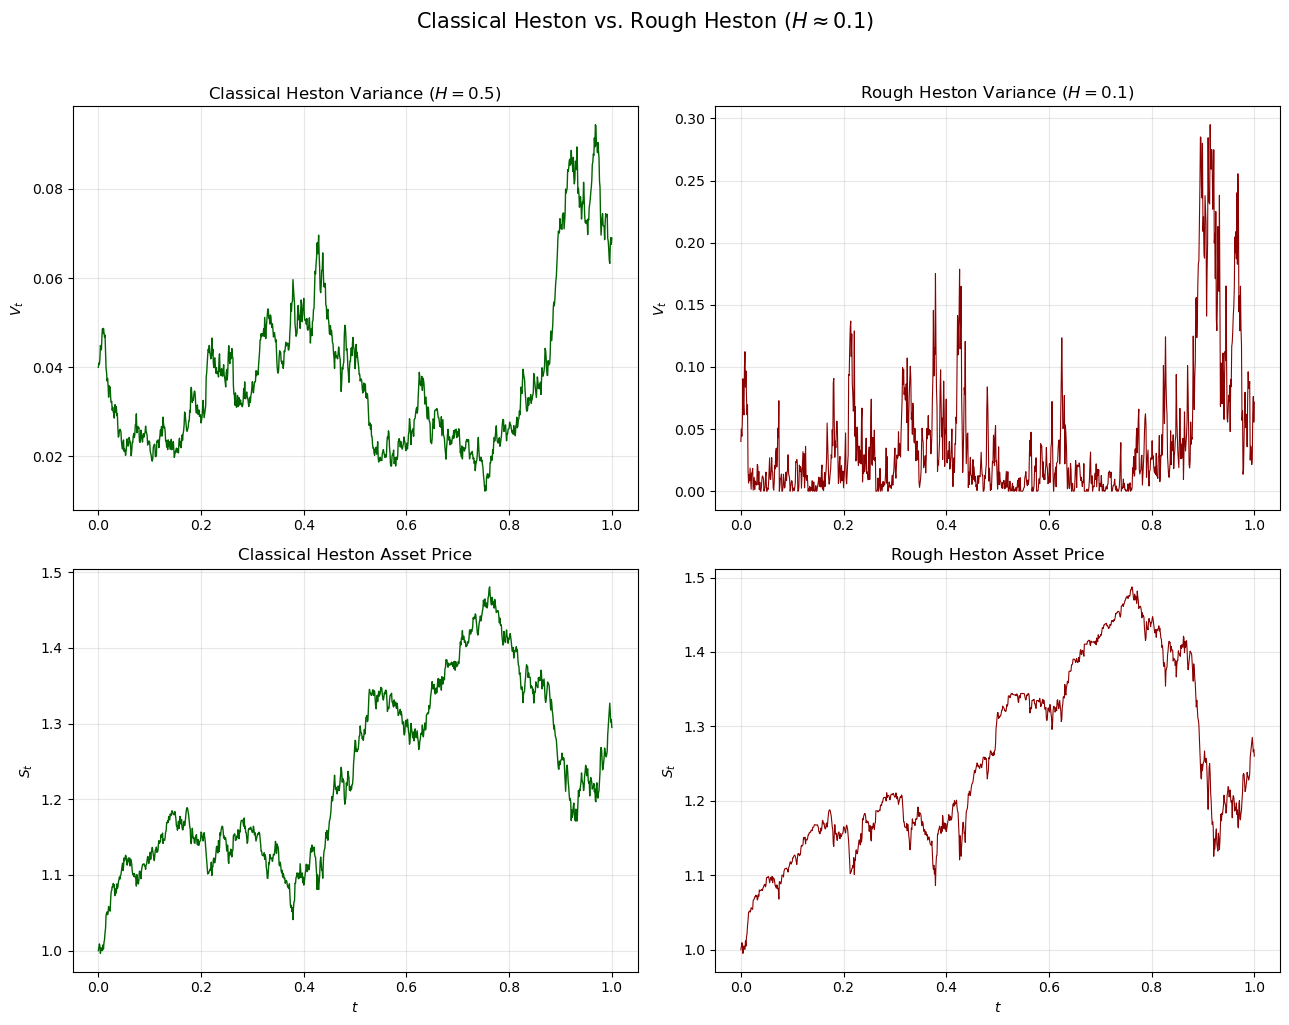


ROUGH HESTON MODEL: KEY TAKEAWAYS
1. Empirical log-volatility has Hurst H ≈ 0.1 (Gatheral et al. 2018).
2. The kernel (t-s)^{H-1/2} is singular for H < 0.5, creating rough paths.
3. The ATM skew explodes at short maturities: ψ(τ) ~ τ^{H-1/2}.
4. The characteristic function solves a FRACTIONAL Riccati equation.
5. The model is non-Markovian and requires convolution-based simulation.
6. For H ≈ 0.1, standard rough path theory needs extensions
   (branched rough paths / regularity structures).


In [9]:
# Final summary figure: side-by-side classical vs rough
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Top-left: Classical Heston variance (H=0.5)
t_cl, V_cl, S_cl = rough_heston_paths(1.0, 1000, 0.5, V0, lambda_param, theta, nu, rho, seed=42)
axes[0, 0].plot(t_cl, V_cl, color='darkgreen', linewidth=1.0)
axes[0, 0].set_title(rf"Classical Heston Variance ($H = 0.5$)", fontsize=12)
axes[0, 0].set_ylabel(r"$V_t$")
axes[0, 0].grid(True, alpha=0.3)

# Top-right: Rough Heston variance (H=0.1)
t_rh, V_rh, S_rh = rough_heston_paths(1.0, 1000, 0.1, V0, lambda_param, theta, nu, rho, seed=42)
axes[0, 1].plot(t_rh, V_rh, color='darkred', linewidth=0.8)
axes[0, 1].set_title(rf"Rough Heston Variance ($H = 0.1$)", fontsize=12)
axes[0, 1].set_ylabel(r"$V_t$")
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: Asset price classical
axes[1, 0].plot(t_cl, S_cl, color='darkgreen', linewidth=1.0)
axes[1, 0].set_title(rf"Classical Heston Asset Price", fontsize=12)
axes[1, 0].set_xlabel(r"$t$")
axes[1, 0].set_ylabel(r"$S_t$")
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: Asset price rough
axes[1, 1].plot(t_rh, S_rh, color='darkred', linewidth=0.8)
axes[1, 1].set_title(rf"Rough Heston Asset Price", fontsize=12)
axes[1, 1].set_xlabel(r"$t$")
axes[1, 1].set_ylabel(r"$S_t$")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Classical Heston vs. Rough Heston ($H \\approx 0.1$)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ROUGH HESTON MODEL: KEY TAKEAWAYS")
print("=" * 70)
print("1. Empirical log-volatility has Hurst H ≈ 0.1 (Gatheral et al. 2018).")
print("2. The kernel (t-s)^{H-1/2} is singular for H < 0.5, creating rough paths.")
print("3. The ATM skew explodes at short maturities: ψ(τ) ~ τ^{H-1/2}.")
print("4. The characteristic function solves a FRACTIONAL Riccati equation.")
print("5. The model is non-Markovian and requires convolution-based simulation.")
print("6. For H ≈ 0.1, standard rough path theory needs extensions")
print("   (branched rough paths / regularity structures).")
print("=" * 70)


## References

- O. El Euch & M. Rosenbaum, *The Characteristic Function of Rough Heston Models* (2019)
- J. Gatheral, T. Jaisson & M. Rosenbaum, *Volatility is Rough* (2018)
- M. Fukasawa, *Asymptotic analysis for stochastic volatility* (2011) — ATM skew scaling law